# 04 — Embeddings & Semantic Similarity

**Threat Incident Intelligence Platform**

This notebook builds sentence embeddings for every incident and prototypes
semantic retrieval (find similar incidents / natural-language search).

Coverage:
- Load incidents from MongoDB
- Compute embeddings with `sentence-transformers`
- Persist embedding matrix + cluster_ids for Streamlit / later notebooks
- Cosine-similarity search demos
- Qualitative relevance checks


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai


In [2]:
from typing import Any, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from src.config import settings, validate_config
from src.db import ping_database, close_connection, count_incidents, find_incidents, find_incident_by_id
from src.preprocessing import clean_text
from src.models.loaders import get_models_dir
from src.utils import setup_logging, timer, truncate_text

logger = setup_logging("INFO", name="embeddings")
validate_config()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

MODELS_DIR = get_models_dir()
print(f"Models directory: {MODELS_DIR}")
print("Setup complete")

[config] MongoDB URI loaded (db=threat_intelligence)
[config] Collections: ['incidents', 'incident_features', 'predictions', 'models_metadata']
Models directory: C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models
Setup complete


In [3]:
if not ping_database():
    raise RuntimeError("Cannot reach MongoDB. Check .env and ensure the server is running.")

total = count_incidents()
print(f"Total incidents: {total:,}")
if total == 0:
    raise RuntimeError("No documents found. Run 01_data_ingestion.ipynb first.")

Total incidents: 19,204


In [4]:
with timer("Loading incidents"):
    docs = find_incidents(
        projection={
            "_id": 0,
            "cluster_id": 1,
            "title": 1,
            "summary": 1,
            "title_clean": 1,
            "summary_clean": 1,
            "keywords": 1,
            "urgency_level": 1,
            "threat_score": 1,
        }
    )

df = pd.DataFrame(docs)
print(f"Shape: {df.shape}")
df.head(2)

[timer] Loading incidents: 0.51s
Shape: (19204, 8)


,cluster_id,title,title_clean,summary,summary_clean,keywords,threat_score,urgency_level
0,971184ec,MikroTik RouterOS Vulnerabilities Under Active...,mikrotik routeros vulnerabilities under active...,CERT Polska has identified six critical vulner...,cert polska has identified six critical vulner...,"[mikrotik, routeros, vulnerability, vulnerabil...",78.65,medium
1,ec7534a8,Cyber Security Roles Address NHS Threats Amid ...,cyber security roles address nhs threats amid ...,Two cybersecurity roles have been announced to...,two cybersecurity roles have been announced to...,"[security, cyber, analyst, remote, consultant,...",39.00,medium


In [5]:
def build_embed_text(row: pd.Series) -> str:
    """Title + summary (cleaned). Keywords optional."""
    title = row.get("title_clean") or clean_text(str(row.get("title") or ""), remove_punctuation=False)
    summary = row.get("summary_clean") or clean_text(str(row.get("summary") or ""), remove_punctuation=False)
    parts = [p for p in [title, summary] if p]
    return " ".join(parts)

with timer("Building embed text"):
    df["embed_text"] = df.apply(build_embed_text, axis=1)

before = len(df)
df = df[df["embed_text"].str.len() > 0].reset_index(drop=True)
print(f"Usable documents: {len(df):,} (dropped {before - len(df):,} empty)")
print(f"Sample: {truncate_text(df['embed_text'].iloc[0], 120)}")

[timer] Building embed text: 0.47s
Usable documents: 19,204 (dropped 0 empty)
Sample: mikrotik routeros vulnerabilities under active exploitation cert polska has identified six critical vulnerabilities in…


In [6]:
MODEL_NAME = "all-MiniLM-L6-v2"
BATCH_SIZE = 64

with timer(f"Loading SentenceTransformer ({MODEL_NAME})"):
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer(MODEL_NAME)

print(f"Model loaded. Embedding dimension: {model.get_sentence_embedding_dimension()}")

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resour


[timer] Loading SentenceTransformer (all-MiniLM-L6-v2): 97.55s
Model loaded. Embedding dimension: 384


C:\Users\hp\AppData\Local\Temp\ipykernel_10336\2002193673.py:8: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded. Embedding dimension: {model.get_sentence_embedding_dimension()}")


In [7]:
texts = df["embed_text"].tolist()

with timer("Encoding all incidents"):
    embeddings = model.encode(
        texts,
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,  # unit-norm → cosine = dot product
    )

print(f"Embeddings shape: {embeddings.shape}")
print(f"dtype: {embeddings.dtype}")
print(f"L2 norms (should be ~1.0): min={np.linalg.norm(embeddings, axis=1).min():.4f}, "
      f"max={np.linalg.norm(embeddings, axis=1).max():.4f}")

Batches:   0%|          | 0/301 [00:00<?, ?it/s]

[timer] Encoding all incidents: 726.64s
Embeddings shape: (19204, 384)
dtype: float32
L2 norms (should be ~1.0): min=1.0000, max=1.0000


In [8]:
emb_path = MODELS_DIR / "embeddings.npy"
ids_path = MODELS_DIR / "cluster_ids.npy"

np.save(emb_path, embeddings)
np.save(ids_path, df["cluster_id"].values)

print(f"Saved embeddings  → {emb_path}  ({embeddings.nbytes / 1e6:.1f} MB)")
print(f"Saved cluster_ids → {ids_path}")
print(f"Artifacts: {[p.name for p in MODELS_DIR.iterdir()]}")

Saved embeddings  → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\embeddings.npy  (29.5 MB)
Saved cluster_ids → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\cluster_ids.npy
Artifacts: ['cluster_ids.npy', 'embeddings.npy', 'tfidf_cluster_ids.npy', 'tfidf_matrix.npz', 'tfidf_vectorizer.joblib']


In [9]:
def cosine_top_k(
    query_vec: np.ndarray,
    matrix: np.ndarray,
    ids: np.ndarray,
    top_k: int = 5,
    exclude_id: Optional[str] = None,
) -> List[Dict[str, Any]]:
    """
    Return top-k most similar items by cosine similarity.
    Assumes matrix rows are already L2-normalised.
    """
    q = query_vec / (np.linalg.norm(query_vec) + 1e-10)
    scores = matrix @ q
    order = np.argsort(scores)[::-1]

    results = []
    for idx in order:
        cid = str(ids[idx])
        if exclude_id and cid == exclude_id:
            continue
        results.append({"cluster_id": cid, "score": float(scores[idx]), "index": int(idx)})
        if len(results) >= top_k:
            break
    return results


def show_results(results: List[Dict[str, Any]], df_ref: pd.DataFrame) -> pd.DataFrame:
    """Join similarity hits with title / urgency for display."""
    rows = []
    id_to_row = df_ref.set_index("cluster_id")
    for r in results:
        cid = r["cluster_id"]
        if cid not in id_to_row.index:
            continue
        rec = id_to_row.loc[cid]
        rows.append({
            "cluster_id": cid,
            "score": round(r["score"], 4),
            "urgency": rec.get("urgency_level"),
            "threat_score": rec.get("threat_score"),
            "title": truncate_text(str(rec.get("title") or ""), 70),
        })
    return pd.DataFrame(rows)

In [10]:
if "threat_score" in df.columns and df["threat_score"].notna().any():
    sample_idx = int(df["threat_score"].fillna(0).idxmax())
else:
    sample_idx = 0

sample_id = df.loc[sample_idx, "cluster_id"]
sample_title = df.loc[sample_idx, "title"]
print(f"Query incident: [{sample_id}]")
print(f"Title: {truncate_text(str(sample_title), 100)}")
print()

hits = cosine_top_k(
    embeddings[sample_idx],
    embeddings,
    df["cluster_id"].values,
    top_k=8,
    exclude_id=sample_id,
)

result_df = show_results(hits, df)
print("Top similar incidents:")
display(result_df)

Query incident: [6a0b6977]
Title: Google Addresses Eighth Chrome Zero-Day Vulnerability in 2025

Top similar incidents:


,cluster_id,score,urgency,threat_score,title
0,45ca7ba0,0.9491,medium,92.31,Google Addresses Eighth Chrome Zero-Day Vulner...
1,671bae65,0.9168,medium,24.31,Google Issues Urgent Update for Chrome Zero-Da...
2,f0d4668c,0.8955,medium,88.71,Google Issues Urgent Update for Chrome 0-Day V...
3,fe0eebdc,0.8911,medium,74.66,Google Releases Emergency Patch for Actively E...
4,54c4b2df,0.8624,medium,66.15,Active Exploitation of Chrome Zero-Day CVE-202...
5,c6278676,0.8589,medium,83.01,Google Chrome Zero-Day Vulnerability CVE-2025-...
6,d21d7c4e,0.8303,medium,80.75,Critical Chrome Zero-Day CVE-2026-85046 Exploi...
7,dfc63fa3,0.8117,medium,83.60,Google and Apple Issue Security Updates for Ze...


In [11]:
QUERIES = [
    "ransomware attack on healthcare hospitals",
    "CVE zero-day vulnerability in VPN appliances",
    "phishing campaign targeting financial sector",
    "supply chain compromise software update",
    "DDoS botnet critical infrastructure",
]

for q in QUERIES:
    print("=" * 70)
    print(f"Query: {q}")
    q_vec = model.encode([q], convert_to_numpy=True, normalize_embeddings=True)[0]
    hits = cosine_top_k(q_vec, embeddings, df["cluster_id"].values, top_k=5)
    display(show_results(hits, df))
    print()

Query: ransomware attack on healthcare hospitals


,cluster_id,score,urgency,threat_score,title
0,6ed2ec78,0.8369,medium,57.71,Ransomware Attacks Targeting Global Healthcare...
1,92c12faf,0.7921,medium,42.29,Ransomware Threats Surge in Healthcare Sector
2,db941034,0.7846,medium,35.71,Ransomware Threats Impacting Healthcare Sector
3,cbd78759,0.7747,medium,69.71,Healthcare Ransomware Attacks Shift Focus to D...
4,89d07211,0.7743,medium,57.91,Ransomware Threats Surge in Healthcare Sector



Query: CVE zero-day vulnerability in VPN appliances


,cluster_id,score,urgency,threat_score,title
0,2f8e9963,0.6541,medium,77.46,China-Linked Hackers Exploit CVE-2025-20393 Ze...
1,8b442c8e,0.6475,medium,94.31,Critical Zero-Day Vulnerability CVE-2025-14733...
2,ecebfbdf,0.6395,medium,78.75,Critical Check Point VPN Vulnerability Exploit...
3,4d1ecf23,0.6279,medium,67.19,Cisco Email Security Products Targeted in Zero...
4,72972ec3,0.6250,medium,40.61,Palo Alto Networks Fixes High-Severity GlobalP...



Query: phishing campaign targeting financial sector


,cluster_id,score,urgency,threat_score,title
0,a523f57b,0.7356,medium,22.31,New Wave of Phishing Targets German Bank Custo...
1,9bc1b4e9,0.6938,medium,31.61,New Work Email Phishing Scam Targets Finance A...
2,c90474d9,0.6885,medium,14.44,Phishing Scam on LinkedIn Targets Finance Lead...
3,3c7e638a,0.6842,medium,57.60,Phishing Campaign Impersonates Economic Securi...
4,47b493f1,0.6824,medium,67.50,Phishing Campaign Targets Marketing Profession...



Query: supply chain compromise software update


,cluster_id,score,urgency,threat_score,title
0,9a94de08,0.6585,medium,30.44,OWASP Top 10 List Updates Address Software Sup...
1,419d5570,0.6226,medium,46.01,Software Supply Chain Threats Surge to OWASP T...
2,a34d103a,0.6113,medium,51.00,Supply Chain Risks Heightened by Changes in So...
3,5c391369,0.5934,medium,66.50,"TeamPCP Compromises Over 1,000 Software Packag..."
4,f5aba69c,0.5910,medium,46.01,OWASP Expands Top 10 List to Address Software ...



Query: DDoS botnet critical infrastructure


,cluster_id,score,urgency,threat_score,title
0,1df8aaf7,0.7326,medium,48.31,Record 29.7 Tbps DDoS Attack by Aisuru Botnet ...
1,69852c43,0.6945,medium,70.50,Surge in DDoS Attacks Over 1 Tbps Amidst Botne...
2,88346a12,0.6752,medium,66.50,"Dysphoria Botnet Compromises 296,000 IoT Devic..."
3,15d5f151,0.6656,medium,54.00,DDoS Attacks Intensify Despite Decrease in Fre...
4,bce0e5bf,0.6627,medium,53.71,DDoS Attack Disrupts Russian Defense Ministry ...


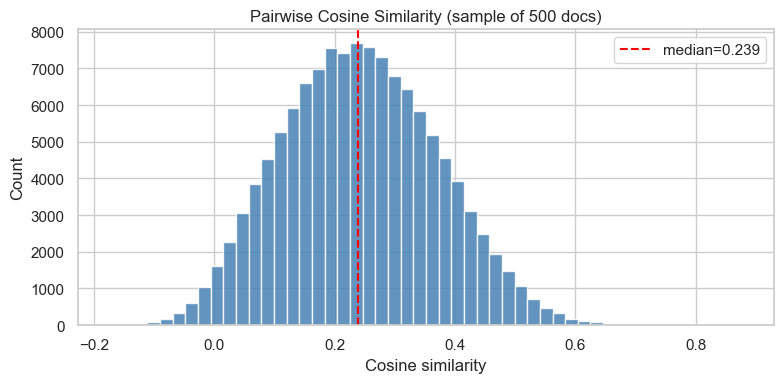

Min=-0.1742  Mean=0.2423  Median=0.2392  Max=0.8776


In [12]:
rng = np.random.default_rng(42)
n_sample = min(500, len(embeddings))
sample_idx = rng.choice(len(embeddings), size=n_sample, replace=False)
sub = embeddings[sample_idx]

sim_matrix = sub @ sub.T
triu_idx = np.triu_indices_from(sim_matrix, k=1)
pairwise = sim_matrix[triu_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairwise, bins=50, edgecolor="white", alpha=0.85, color="steelblue")
ax.axvline(np.median(pairwise), color="red", linestyle="--", label=f"median={np.median(pairwise):.3f}")
ax.set_title(f"Pairwise Cosine Similarity (sample of {n_sample} docs)")
ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Min={pairwise.min():.4f}  Mean={pairwise.mean():.4f}  "
      f"Median={np.median(pairwise):.4f}  Max={pairwise.max():.4f}")

In [13]:
from src.models.predictors import find_similar_incidents

test_query = "ransomware healthcare data breach"
shared_hits = find_similar_incidents(
    test_query,
    top_k=5,
    embeddings=embeddings,
    cluster_ids=df["cluster_id"].values,
    sentence_model=model,
)

print(f"Query via src.models.predictors: '{test_query}'")
for h in shared_hits:
    doc = find_incident_by_id(h["cluster_id"])
    title = truncate_text(str(doc.get("title") if doc else "?"), 60)
    print(f"  {h['score']:.4f}  [{h['cluster_id']}]  {title}")

Query via src.models.predictors: 'ransomware healthcare data breach'
  0.7888  [6ed2ec78]  Ransomware Attacks Targeting Global Healthcare Institutions
  0.7849  [cbd78759]  Healthcare Ransomware Attacks Shift Focus to Data Extortion…
  0.7838  [a47633d9]  2025 Healthcare Data Breaches Surge with Smaller Data Compr…
  0.7810  [3ed23818]  Massive Data Breach at Change Healthcare Affects 190 Millio…
  0.7755  [db941034]  Ransomware Threats Impacting Healthcare Sector


In [15]:
print("=" * 60)
print("EMBEDDINGS & SIMILARITY REPORT")
print("=" * 60)
print(f"Model                  : {MODEL_NAME}")
print(f"Documents embedded     : {len(df):,}")
print(f"Embedding dimension    : {embeddings.shape[1]}")
print(f"Embeddings file        : {emb_path}")
print(f"Cluster IDs file       : {ids_path}")
print(f"Normalised             : True (cosine = dot product)")

EMBEDDINGS & SIMILARITY REPORT
Model                  : all-MiniLM-L6-v2
Documents embedded     : 19,204
Embedding dimension    : 384
Embeddings file        : C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\embeddings.npy
Cluster IDs file       : C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\cluster_ids.npy
Normalised             : True (cosine = dot product)


In [16]:
close_connection()
print("MongoDB connection closed.")

MongoDB connection closed.
